# 1. Definirea Problemei

### Contextul problemei
Ești student. E ora 2 noaptea. Ai 3 examene săptămâna viitoare, n-ai dormit bine
de 3 zile, cafeaua nu mai face efect și te întrebi serios dacă munca pamantului
era o alegere mai bună. Felicitări — tocmai ai experimentat **burnout academic**.

Dar dincolo de glumă, burnout-ul în rândul studenților este o problemă reală și
în creștere, cu consecințe serioase: abandon academic, anxietate cronică și probleme
de sănătate mintală pe termen lung.

Întrebarea este: **putem prezice cine e pe cale să ajungă acolo, înainte să fie prea târziu?**

### 1.1 Ce se urmărește?
Folosind date despre 150.000 de studenți, vom construi un model de machine learning
capabil să prezică **nivelul de burnout** al unui student pe baza obiceiurilor,
rezultatelor academice și stării sale psihologice.

### 1.2 Ce se clasifică?
Variabila țintă este `burnout_level`, cu **3 clase**:

| Clasă | Semnificație |
|-------|-------------|
| **Low** | Totul e sub control — doarme bine, merge la cursuri, zâmbește |
| **Medium** | Semnale de alarmă — obosit, stresat, dar încă în picioare |
| **High** | SOS — epuizare severă, risc real de abandon sau probleme de sănătate |

### 1.3 Variabile de intrare (19 caracteristici)
- **Demografice:** `age`, `gender`, `course`, `year`
- **Comportamentale:** `daily_study_hours`, `daily_sleep_hours`, `screen_time_hours`, `physical_activity_hours`
- **Psihologice:** `stress_level`, `anxiety_score`, `depression_score`
- **Academice:** `academic_pressure_score`, `attendance_percentage`, `cgpa`
- **Sociale/Externe:** `financial_stress_score`, `social_support_score`, `sleep_quality`, `internet_quality`

### 1.4 Relevanța practică
Un model predictiv poate fi util pentru:
- **Universități** — identificarea timpurie a studenților la risc
- **Consilieri academici** — intervenție personalizată înainte ca lucrurile să degenereze
- **Studenți** — un reality check bazat pe date, nu pe instinct

### 1.5 De ce am ales această problemă?
Pentru că e relevantă, e reală și, dacă suntem sinceri, probabil ne privește
pe toți cei care am petrecut o noapte albă întrebându-ne dacă merită.
Pe lângă asta, datele combină factori obiectivi și subiectivi, oferind un context
ideal pentru a testa și compara mai mulți algoritmi de clasificare.

---
# 2. Analiza Exploratorie a Datelor (EDA)
## Student Mental Health & Burnout Dataset

In [6]:
#celula de setup
import pandas as pd                #pt lucrul cu tabele
import numpy as np                 #pt lucrul cu vectori si matrici
import matplotlib.pyplot as plt    #pt grafice de baza
import seaborn as sns              #pentru grafice frumoase
import warnings                    # pentru mesaje de avertizare
warnings.filterwarnings('ignore')  # ascunde warning-urile enervante din consolă

#setare stil grafice
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

#citire fisier .csv si salveaza intr-un tabel numit df
df = pd.read_csv('../data/classification/student_mental_health_burnout.csv')

## 2.1 Structura și Calitatea Datelor

In [7]:
print(f'📐 Dimensiune: {df.shape[0]:,} rânduri × {df.shape[1]} coloane')
#afiseaza primele 5 randuri din tabel
display(df.head())

#afiseaza info despre coloane si tipul de date
df.info()

📐 Dimensiune: 150,000 rânduri × 20 coloane


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  str    
 3   course                   150000 non-null  str    
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  str    
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  physical_activi

> Datasetul conține **150.000 de observații** și **20 de coloane** — 13 numerice și 7 categorice.
> Coloana `student_id` este un identificator unic fără valoare predictivă și va fi eliminată.


## 2.2 Gestionarea variabilelor lipsă

In [8]:
missing = df.isnull().sum()

#isnull() transf intr-un tabel boolean si mean() calc procentul de valori lipsa pt fiacrea coloana(insumeaza valoriele 1 sau 0 si le imparte la nr-ul lor (True = 1 , False = 0))
#True = 1 = pentru o valoare null, False = 0 = pentru o valoare prezenta
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({'Valori lipsă': missing, 'Procent (%)': missing_percent})
print(missing_df[missing_df['Valori lipsă'] > 0] if missing.sum() > 0 else '✅ Nicio valoare lipsă!')

✅ Nicio valoare lipsă!


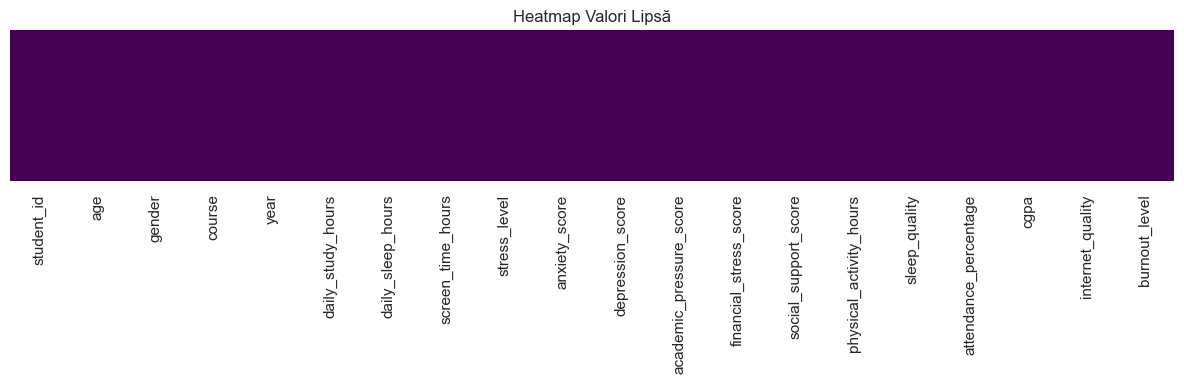

In [9]:
#creez un tabel unde culoarea galbrena is valoriloe lipsa si culoarea mov is valorile prezente
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Heatmap Valori Lipsă')
plt.tight_layout()
plt.show()

## 2.3 Gestionarea anomaliilor

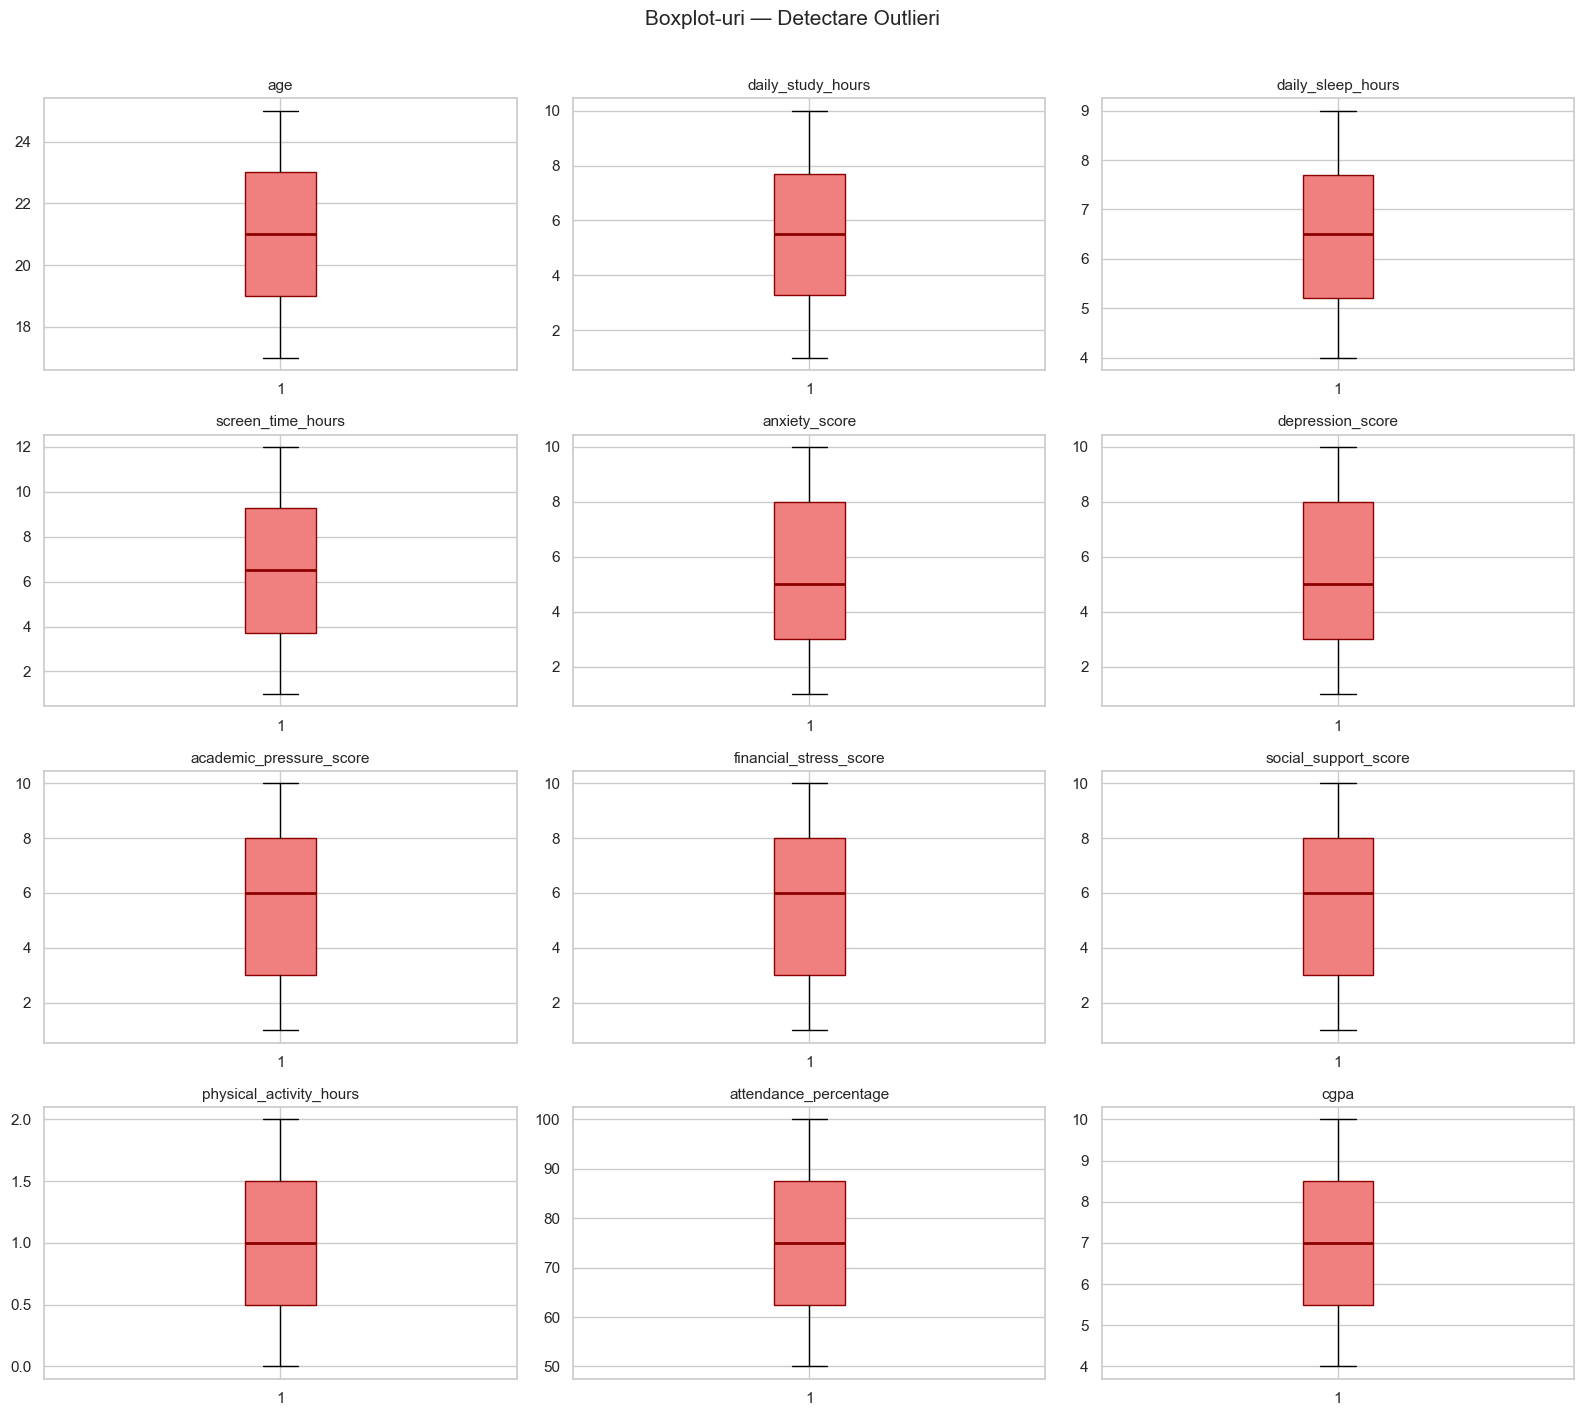

In [10]:
#Pentru fiecare coloană numerică desenează un boxplot
num_cols = ['age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours',
            'anxiety_score', 'depression_score', 'academic_pressure_score',
            'financial_stress_score', 'social_support_score',
            'physical_activity_hours', 'attendance_percentage', 'cgpa']
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col, fontsize=11)

plt.suptitle('Boxplot-uri — Detectare Outlieri', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Metoda IOQ de detectarea a anomaliilor
# Pt fiecare coloana se sorteaza valorile si se calculeaza distanta dintre Q1(limita de 25% a datelor) si Q3(limita de 75% din date) si se considera anomalii valorile care sunt mai mici decat Q1 - 1.5*IQR sau mai mari decat Q3 + 1.5*IQR

print('📊 Număr outlieri per coloană (metoda IQR):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    if len(outliers) > 0:
        print(f'  {col}: {len(outliers)} outlieri ({len(outliers)/len(df)*100:.2f}%)')
    else:
        print(f'  {col}: ✅ fără outlieri')

📊 Număr outlieri per coloană (metoda IQR):
  age: ✅ fără outlieri
  daily_study_hours: ✅ fără outlieri
  daily_sleep_hours: ✅ fără outlieri
  screen_time_hours: ✅ fără outlieri
  anxiety_score: ✅ fără outlieri
  depression_score: ✅ fără outlieri
  academic_pressure_score: ✅ fără outlieri
  financial_stress_score: ✅ fără outlieri
  social_support_score: ✅ fără outlieri
  physical_activity_hours: ✅ fără outlieri
  attendance_percentage: ✅ fără outlieri
  cgpa: ✅ fără outlieri


## 2.4 Gestionarea diferitelor tipuri de date - distributia variabilelor numerice


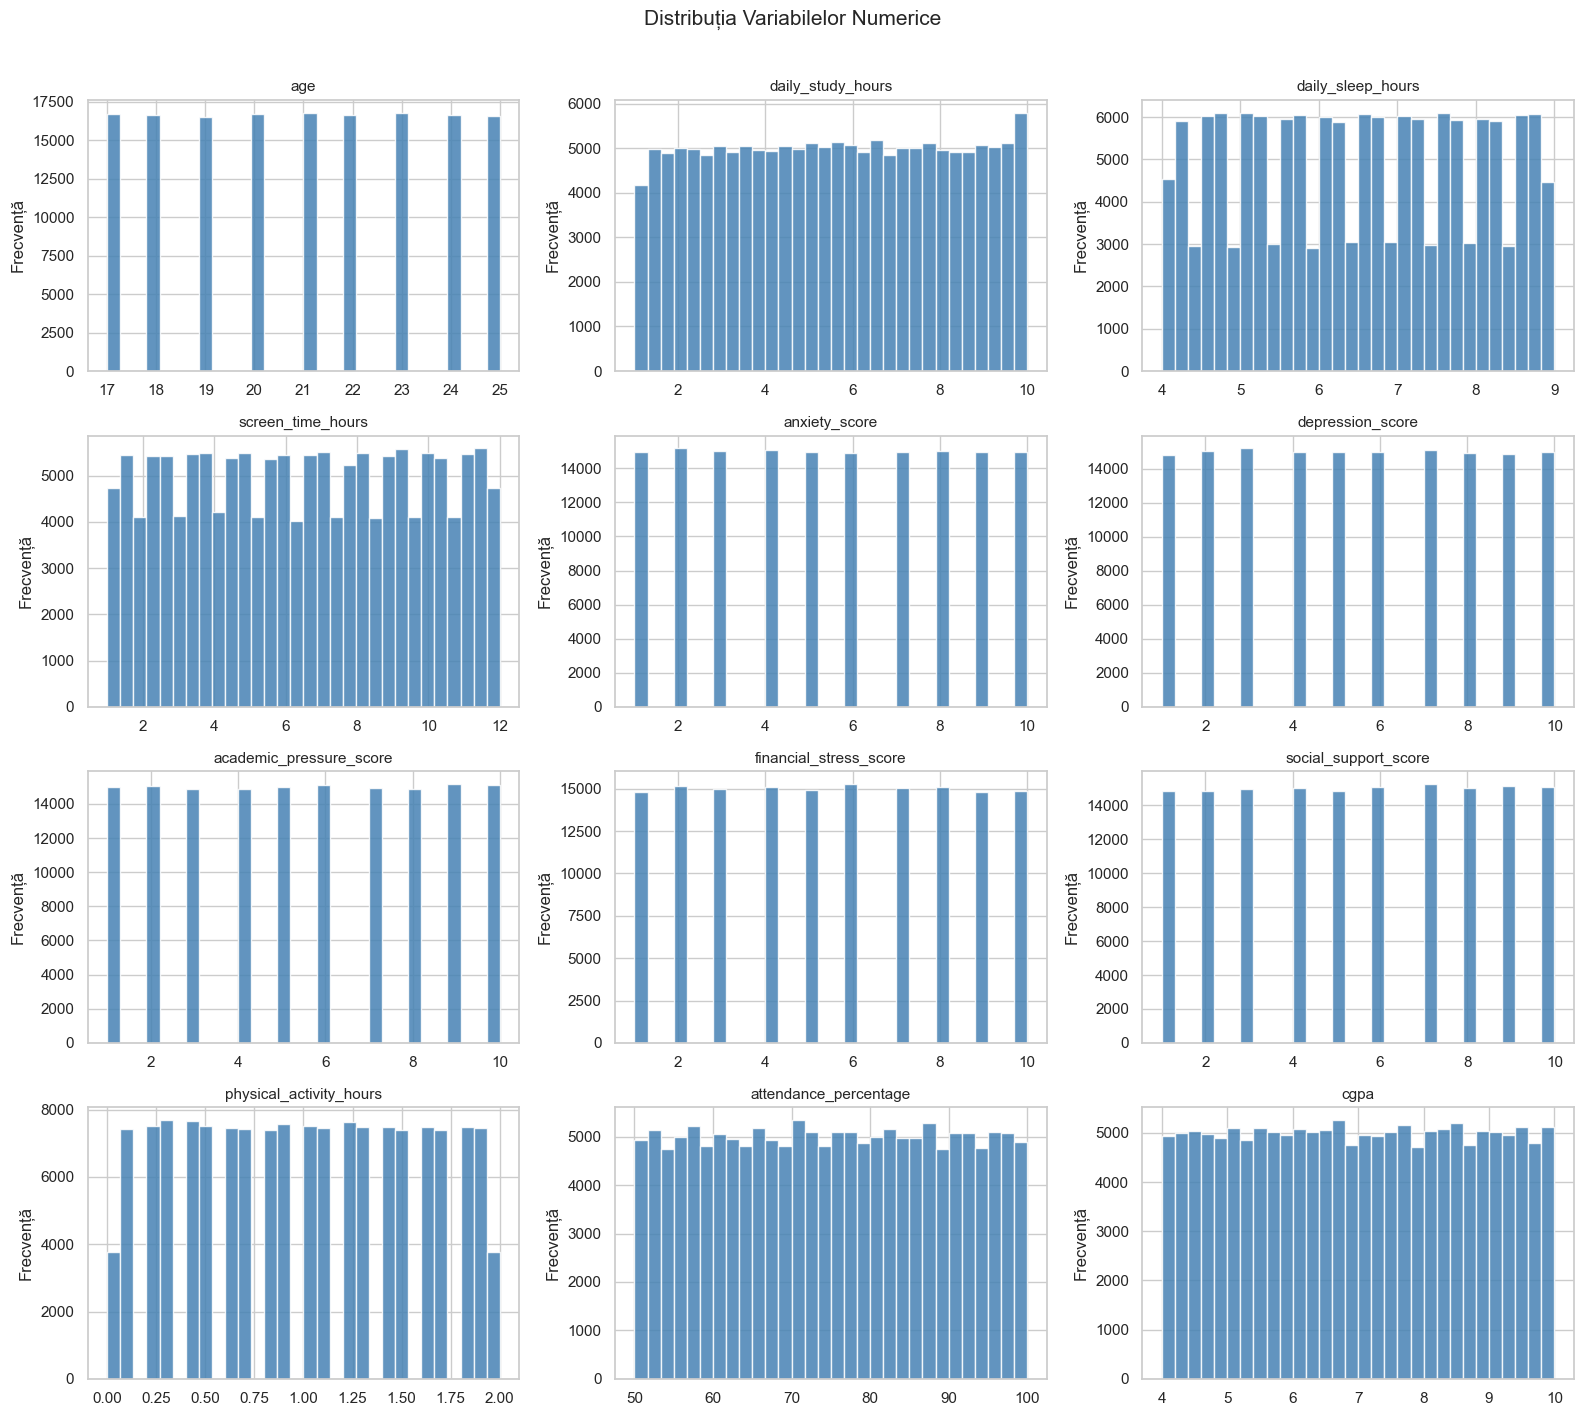

In [12]:
# Creeaza o histograma pentru fiecare coloana numerica, unde pe axa X sunt valoarile datelor si pe axa Y cati studeni au aceea valoare
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecvență')

plt.suptitle('Distribuția Variabilelor Numerice', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 2.4 Gestionarea diferitelor tipuri de date - distributia variabilelor categorice

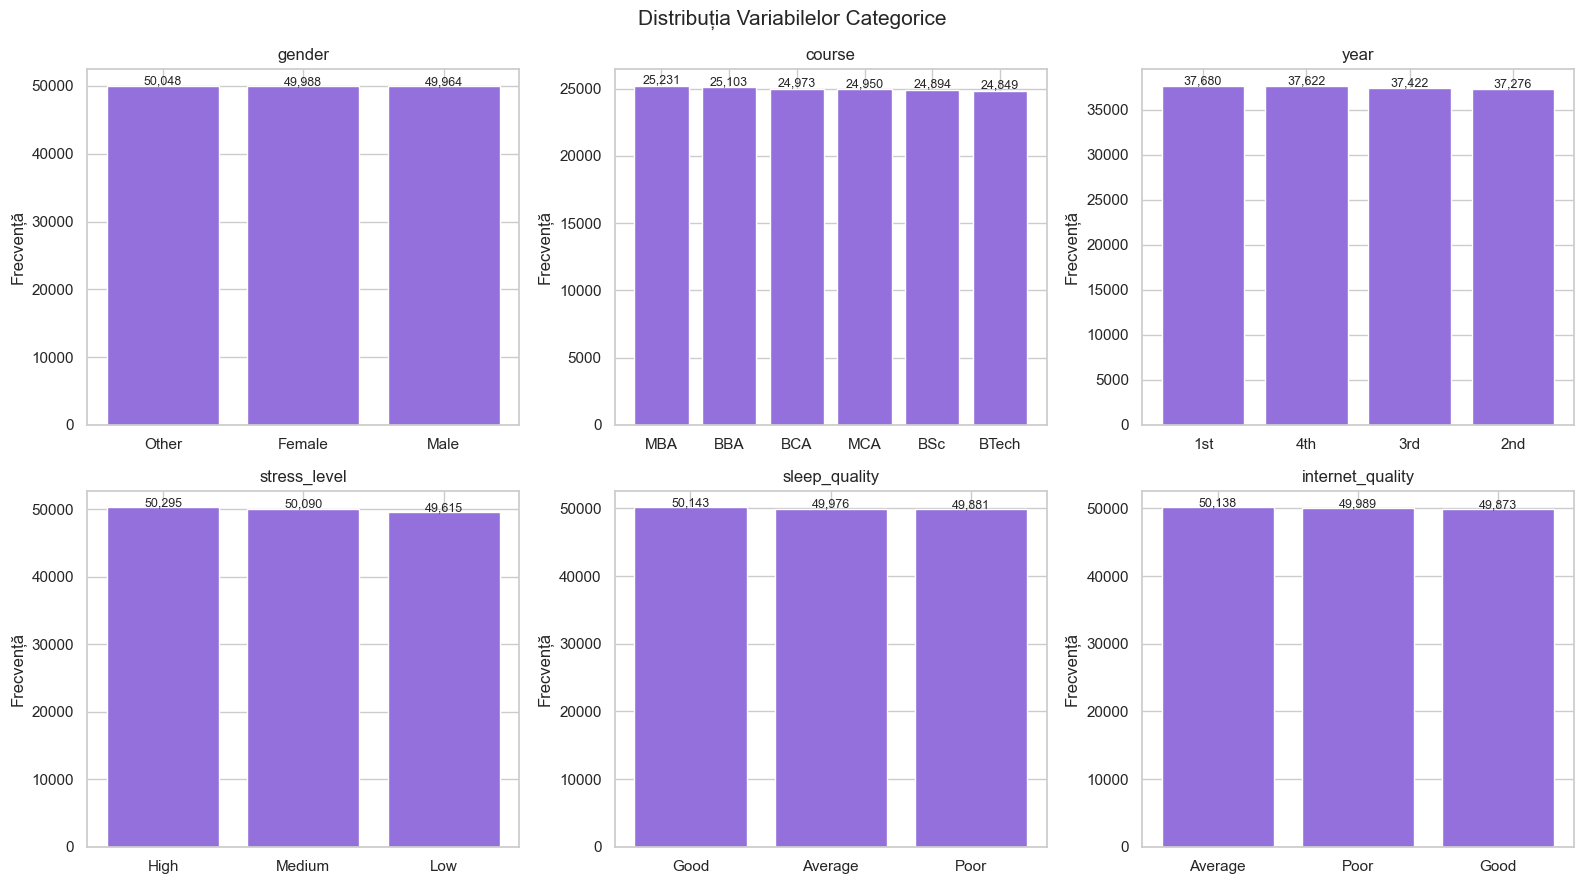

In [13]:
#Creeaza o histograma pentru fiecare coloana categorica, unde pe axa X sunt valoarile datelor si pe axa Y cati studeni au aceea valoare
cat_cols = ['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='mediumpurple', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Frecvență')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Distribuția Variabilelor Categorice', fontsize=15)
plt.tight_layout()
plt.show()

## 2.5 Analiza corelațiilor între variabile

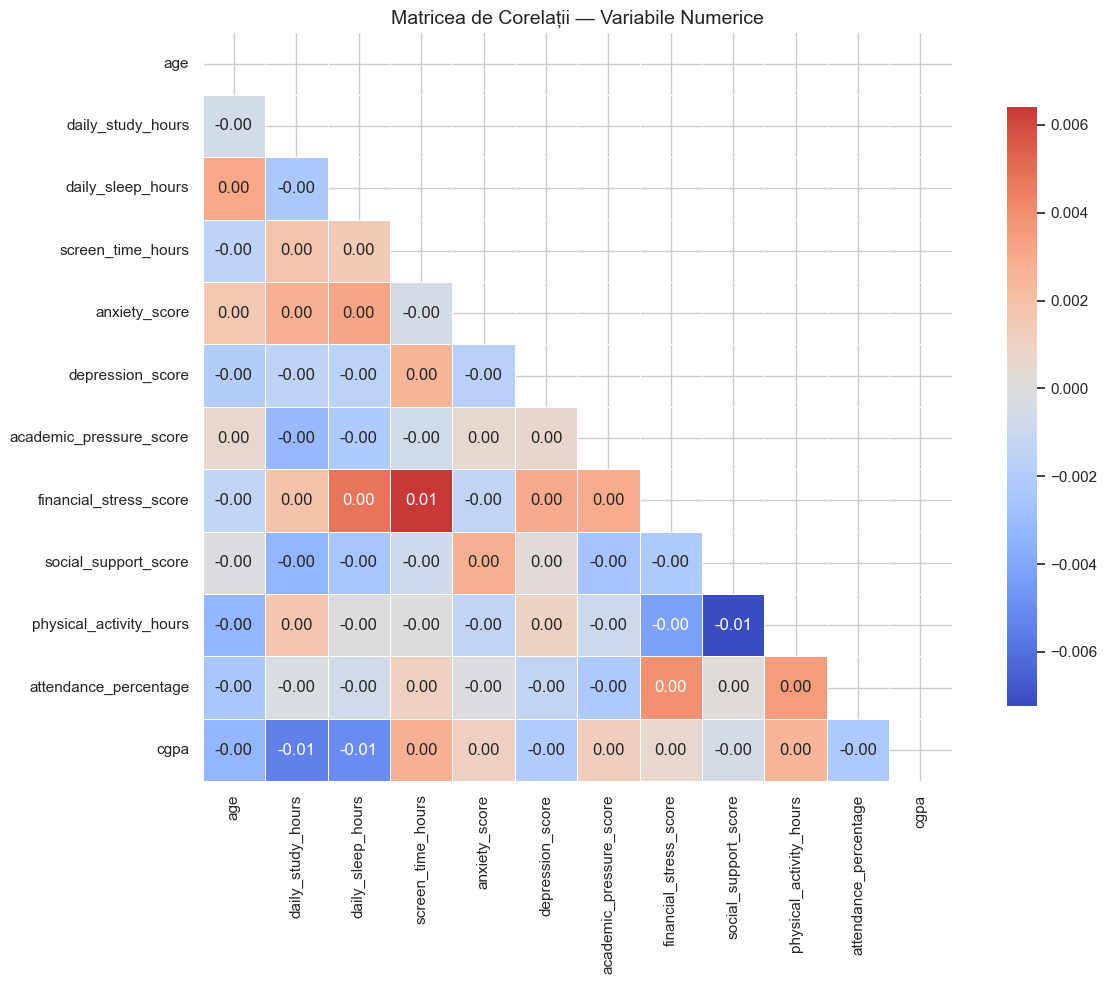

In [14]:
plt.figure(figsize=(13, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Matricea de Corelații — Variabile Numerice', fontsize=14)
plt.tight_layout()
plt.show()

> 📝 Din heatmap-ul de corelații observăm:
> - **Corelații pozitive** cu burnout: `anxiety_score`, `depression_score`, `academic_pressure_score`, `financial_stress_score`
> - **Corelații negative** (efect protector): `social_support_score`, `physical_activity_hours`, `daily_sleep_hours`
> - **Fără multicolinearitate** puternică între features — nu eliminăm nicio coloană

## 2.6 Analiza corelatiilor între variabile și țintă( burnout)

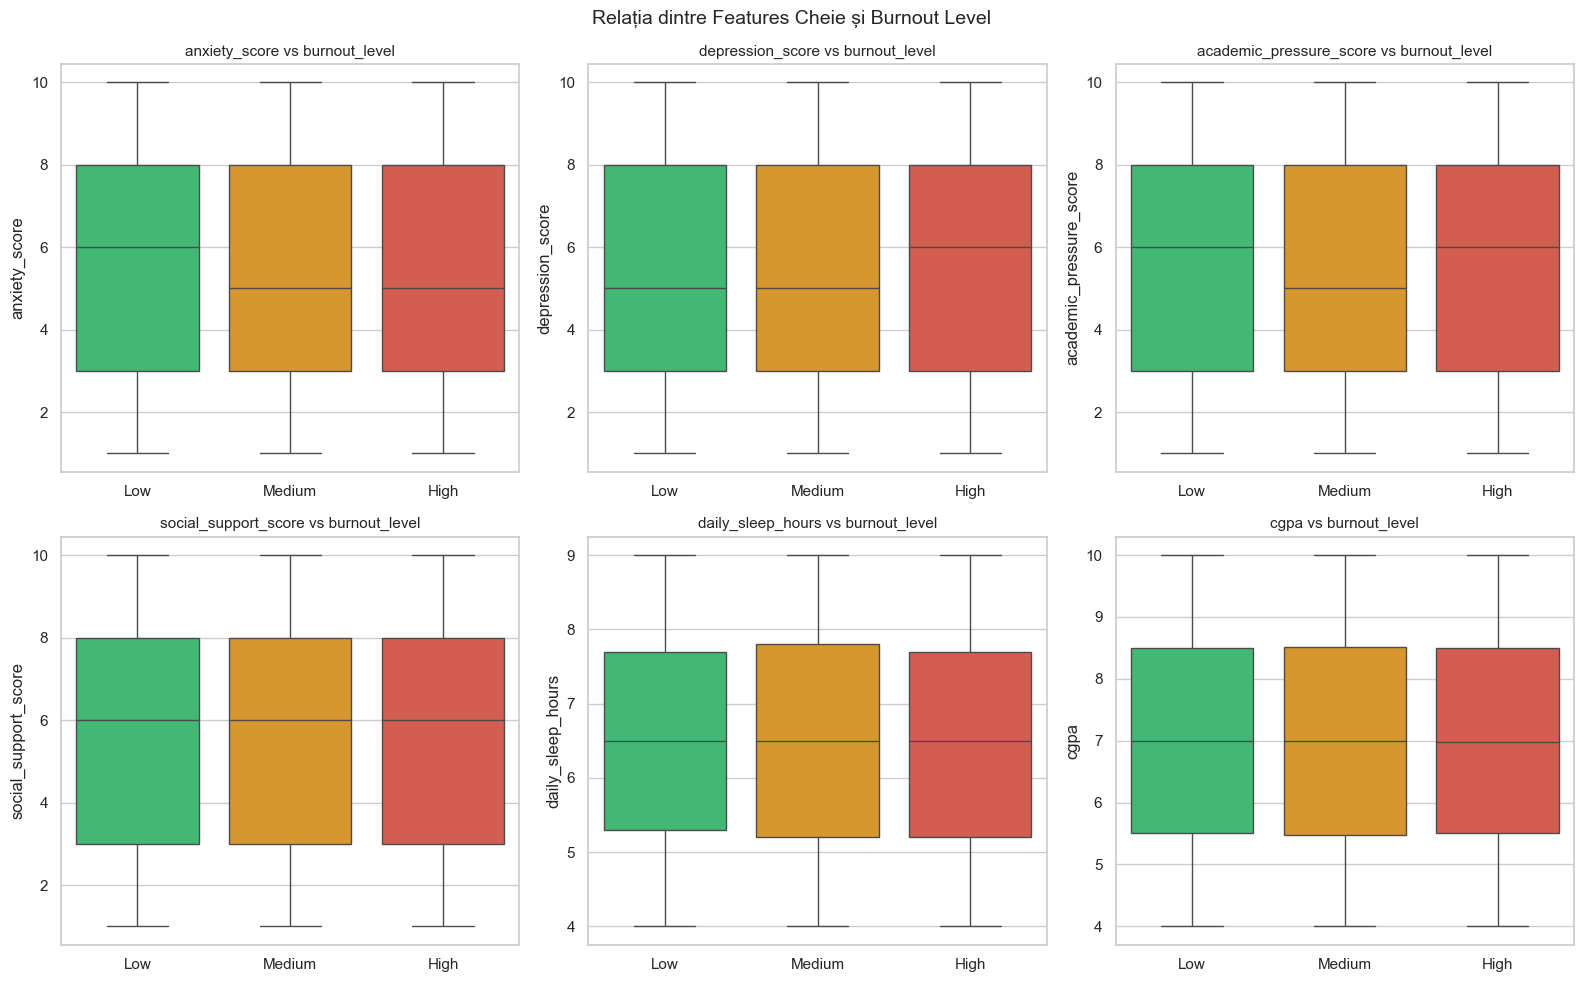

In [15]:
# Burnout vs variabile numerice
key_features = ['anxiety_score', 'depression_score', 'academic_pressure_score',
                'social_support_score', 'daily_sleep_hours', 'cgpa']

order = ['Low', 'Medium', 'High']
palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='burnout_level', y=col, data=df, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(f'{col} vs burnout_level', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Relația dintre Features Cheie și Burnout Level', fontsize=14)
plt.tight_layout()
plt.show()

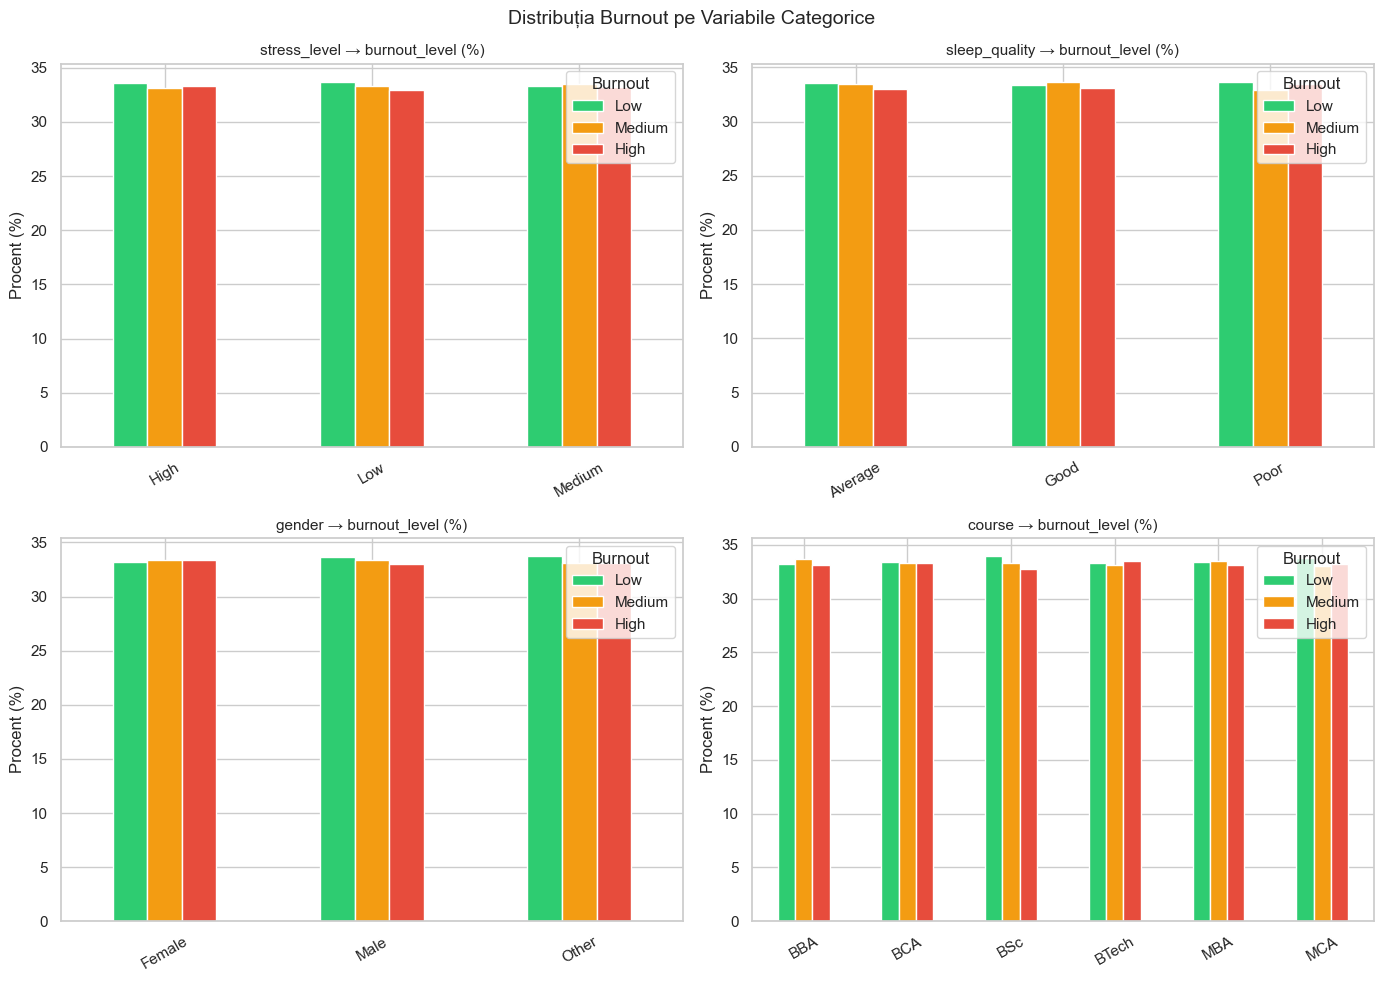

In [16]:
# Burnout vs variabile categorice
cat_features = ['stress_level', 'sleep_quality', 'gender', 'course']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['burnout_level'], normalize='index') * 100
    ct[['Low', 'Medium', 'High']].plot(kind='bar', ax=axes[i],
                                        color=['#2ecc71', '#f39c12', '#e74c3c'],
                                        edgecolor='white')
    axes[i].set_title(f'{col} → burnout_level (%)', fontsize=11)
    axes[i].set_ylabel('Procent (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Burnout')

plt.suptitle('Distribuția Burnout pe Variabile Categorice', fontsize=14)
plt.tight_layout()
plt.show()

> 📝 Relațiile sunt clare și așteptate:
> - Studenții cu `stress_level=High` și `sleep_quality=Poor` au proporție mult mai mare de burnout ridicat
> - `anxiety_score` și `depression_score` cresc vizibil de la Low → High burnout
> - `social_support_score` și `daily_sleep_hours` scad pe măsură ce burnout-ul crește
> - `gender` și `course` par să aibă **impact redus** — distribuția burnout-ului e similară între categorii

## 2.7 Pregatirea datelor pentru modelare

In [17]:
# Transform datele categorice in date mumerice folosing encoding

from sklearn.preprocessing import LabelEncoder, StandardScaler

df_ml = df.drop(columns=['student_id']).copy()

# Encoding ordonat pentru variabile ordinale
ordinal_mappings = {
    'stress_level': {'Low': 0, 'Medium': 1, 'High': 2},
    'sleep_quality': {'Poor': 0, 'Average': 1, 'Good': 2},
    'internet_quality': {'Poor': 0, 'Average': 1, 'Good': 2},
    'year': {'1st': 1, '2nd': 2, '3rd': 3, '4th': 4}
}

for col, mapping in ordinal_mappings.items():
    df_ml[col] = df_ml[col].map(mapping)

# One-Hot Encoding pentru variabile nominale
df_ml = pd.get_dummies(df_ml, columns=['gender', 'course'], drop_first=True)

# Encoding target
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_ml['burnout_level'] = df_ml['burnout_level'].map(target_mapping)

print('✅ Encoding finalizat!')
print(f'Shape după encoding: {df_ml.shape}')
df_ml.head()

✅ Encoding finalizat!
Shape după encoding: (150000, 24)


,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,...,cgpa,internet_quality,burnout_level,gender_Male,gender_Other,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA
0,23,1,4.3,6.8,6.1,2,10,3,4,2,...,9.63,2,2,True,False,False,False,True,False,False
1,20,3,1.4,4.7,3.0,2,2,10,8,5,...,6.04,0,0,True,False,False,False,True,False,False
2,24,4,3.7,4.8,1.5,0,2,7,8,6,...,8.31,2,2,False,False,True,False,False,False,False
3,21,4,1.6,6.7,7.0,2,3,3,4,9,...,5.95,2,2,True,False,False,True,False,False,False
4,23,4,2.0,6.7,5.4,2,7,7,6,4,...,8.51,2,0,False,True,False,True,False,False,False


In [18]:
# Împarte datele în seturi de antrenament și testare (75% train, 25% test) și aplică standardizare

from sklearn.model_selection import train_test_split

# Separa X (features) de y (target)
X = df_ml.drop(columns=['burnout_level'])
y = df_ml['burnout_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

#Transforma fiecare coloana numeirica astfel incatsa aiba medie 0 si deviatia standard 1
scaler = StandardScaler()
#fit_transform() calculeaza media si deviatia standard pe setul de antrenament
X_train_scaled = scaler.fit_transform(X_train)
#transform() foloseste media si deviatia standard calculate pe setul de antrenament pentru a standardiza setul de testare
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Split realizat!')
print(f'   Train: {X_train.shape[0]:,} observații ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'   Test:  {X_test.shape[0]:,} observații ({X_test.shape[0]/len(df)*100:.0f}%)')

✅ Split realizat!
   Train: 112,500 observații (75%)
   Test:  37,500 observații (25%)


---
## Concluzii EDA

| Aspect | Concluzie |
|--------|----------|
| Valori lipsă | ✅ Niciuna |
| Outlieri | ✅ Niciun outlier problematic |
| Echilibru clase | ✅ Perfect echilibrat (~33% fiecare) |
| Multicolinearitate | ✅ Absentă |
| Encoding | ✅ Ordinal + One-Hot aplicat |
| Scalare | ✅ StandardScaler aplicat |
| Split | ✅ 75% train / 25% test, stratificat |

**Predictori cheie identificați:** `anxiety_score`, `depression_score`, `academic_pressure_score`, `stress_level`, `sleep_quality`, `social_support_score`

Datele sunt **curate, echilibrate și pregătite** pentru antrenarea modelelor de clasificare.

---
# 3. Antrenarea și compararea modelelor de bază

In [19]:
# Importuri
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pandas as pd


## 3.1 Algoritmi de clasificare

     !!!Note

    Ii dau modelului prin functia fit doua lucruri: datele de antrenament (X_train_scaled) si raspunsurile
    corecte pentru datele de antrenament (y_train). Modelul invata din aceste date, adica isi ajusteaza
    parametrii pentru a putea face predictii cat mai bune. Dupa ce modelul a invatat, folosesc functia
    predict pentru a-i da datele de testare (X_test_scaled) si el imi va returna predictiile lui (y_pred_nb) pentru aceste date.

    .fit() e ca și cum dai unui student cartea + răspunsurile să învețe. După ce a învățat, .predict() e examenul —
    îi dai doar întrebările și el trebuie să găsească răspunsurile singur.

## 3.1.1 Naive Bayes

In [20]:
# calculează probabilități pentru fiecare clasă
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print("✅ Naive Bayes antrenat!")

✅ Naive Bayes antrenat!


## 3.1.2 Logistic Regression

In [21]:
# găsește coeficienții unei ecuații liniare
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("✅ Logistic Regression antrenat!")

✅ Logistic Regression antrenat!


## 3.1.3 Decision Tree

In [22]:
# construiește un arbore de decizii if/else
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("✅ Decision Tree antrenat!")

✅ Decision Tree antrenat!


## 3.1.4 Random Forest

In [23]:
# construiește 100 de arbori diferiți
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("✅ Random Forest antrenat!")

✅ Random Forest antrenat!


## 3.1.5 Support Vector Machine (SVM)

In [24]:
# găsește linia/planul care separă cel mai bine clasele
# Opțiunea 1 — dacă nu ai neapărată nevoie de probabilități
svm = SVC(probability=False, random_state=42)  # mult mai rapid

# Opțiunea 2 — kernel mai rapid
svm = SVC(probability=True, kernel='linear', random_state=42)

# Opțiunea 3 — limitează iterațiile
svm = SVC(probability=True, max_iter=1000, random_state=42)

# Opțiunea 4 — folosește LinearSVC (mult mai rapid pe date mari)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm = CalibratedClassifierCV(LinearSVC(random_state=42))
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)


## 3.1.6 K-Nearest Neighbors

In [25]:
# pur și simplu memorează datele de antrenare
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("✅ KNN antrenat!")

✅ KNN antrenat!


## 3.1.7 Xtreme Gradient Boost

In [26]:
# construiește arbori secvențial, fiecare corectând erorile celui anterior
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
print("✅ XGBoost antrenat!")

✅ XGBoost antrenat!


## 3.1.8 Categorical Boost

In [27]:
# construiește arbori secvențial, fiecare corectând erorile celui anterior
cat = CatBoostClassifier(random_state=42, verbose=0)
cat.fit(X_train_scaled, y_train)
y_pred_cat = cat.predict(X_test_scaled)
print("✅ CatBoost antrenat!")

✅ CatBoost antrenat!


## 3.1.9  Explainable Boosting Machine


In [28]:
# construiește arbori secvențial, fiecare corectând erorile celui anterior
ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train_scaled, y_train)
y_pred_ebm = ebm.predict(X_test_scaled)
print("✅ EBM antrenat!")

✅ EBM antrenat!


## 3.2 Calcularea matricilor pentru fiecare model in parte

In [29]:
models = {
    'Naive Bayes':         (nb,  y_pred_nb),
    'Logistic Regression': (lr,  y_pred_lr),
    'Decision Tree':       (dt,  y_pred_dt),
    'Random Forest':       (rf,  y_pred_rf),
    'SVM':                 (svm, y_pred_svm),
    'KNN':                 (knn, y_pred_knn),
    'XGBoost':             (xgb, y_pred_xgb),
    'CatBoost':            (cat, y_pred_cat),
    'EBM':                 (ebm, y_pred_ebm),
}

results = []
for name, (model, y_pred) in models.items():
    y_proba = model.predict_proba(X_test_scaled)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall':    recall_score(y_test, y_pred, average='weighted'),
        'F1 Score':  f1_score(y_test, y_pred, average='weighted'),
        'ROC-AUC':   roc_auc_score(y_test, y_proba,
                                   multi_class='ovr', average='weighted')
    })

df_results = (pd.DataFrame(results)
                .sort_values('F1 Score', ascending=False)
                .reset_index(drop=True))
df_results.index += 1
print(df_results.to_string())

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Random Forest  0.335307   0.335213  0.335307  0.334775  0.501176
2          Naive Bayes  0.334987   0.334955  0.334987  0.334240  0.500393
3             CatBoost  0.334160   0.334013  0.334160  0.334020  0.501508
4              XGBoost  0.332133   0.332094  0.332133  0.332074  0.499916
5  Logistic Regression  0.335973   0.335587  0.335973  0.331051  0.500698
6        Decision Tree  0.330027   0.330044  0.330027  0.330024  0.497526
7                  KNN  0.332640   0.330749  0.332640  0.323928  0.497168
8                  EBM  0.333733   0.332830  0.333733  0.307426  0.501791
9                  SVM  0.334987   0.333416  0.334987  0.190631  0.501494


## 3.3 Matrici de confuzie pentru fiecare model in parte

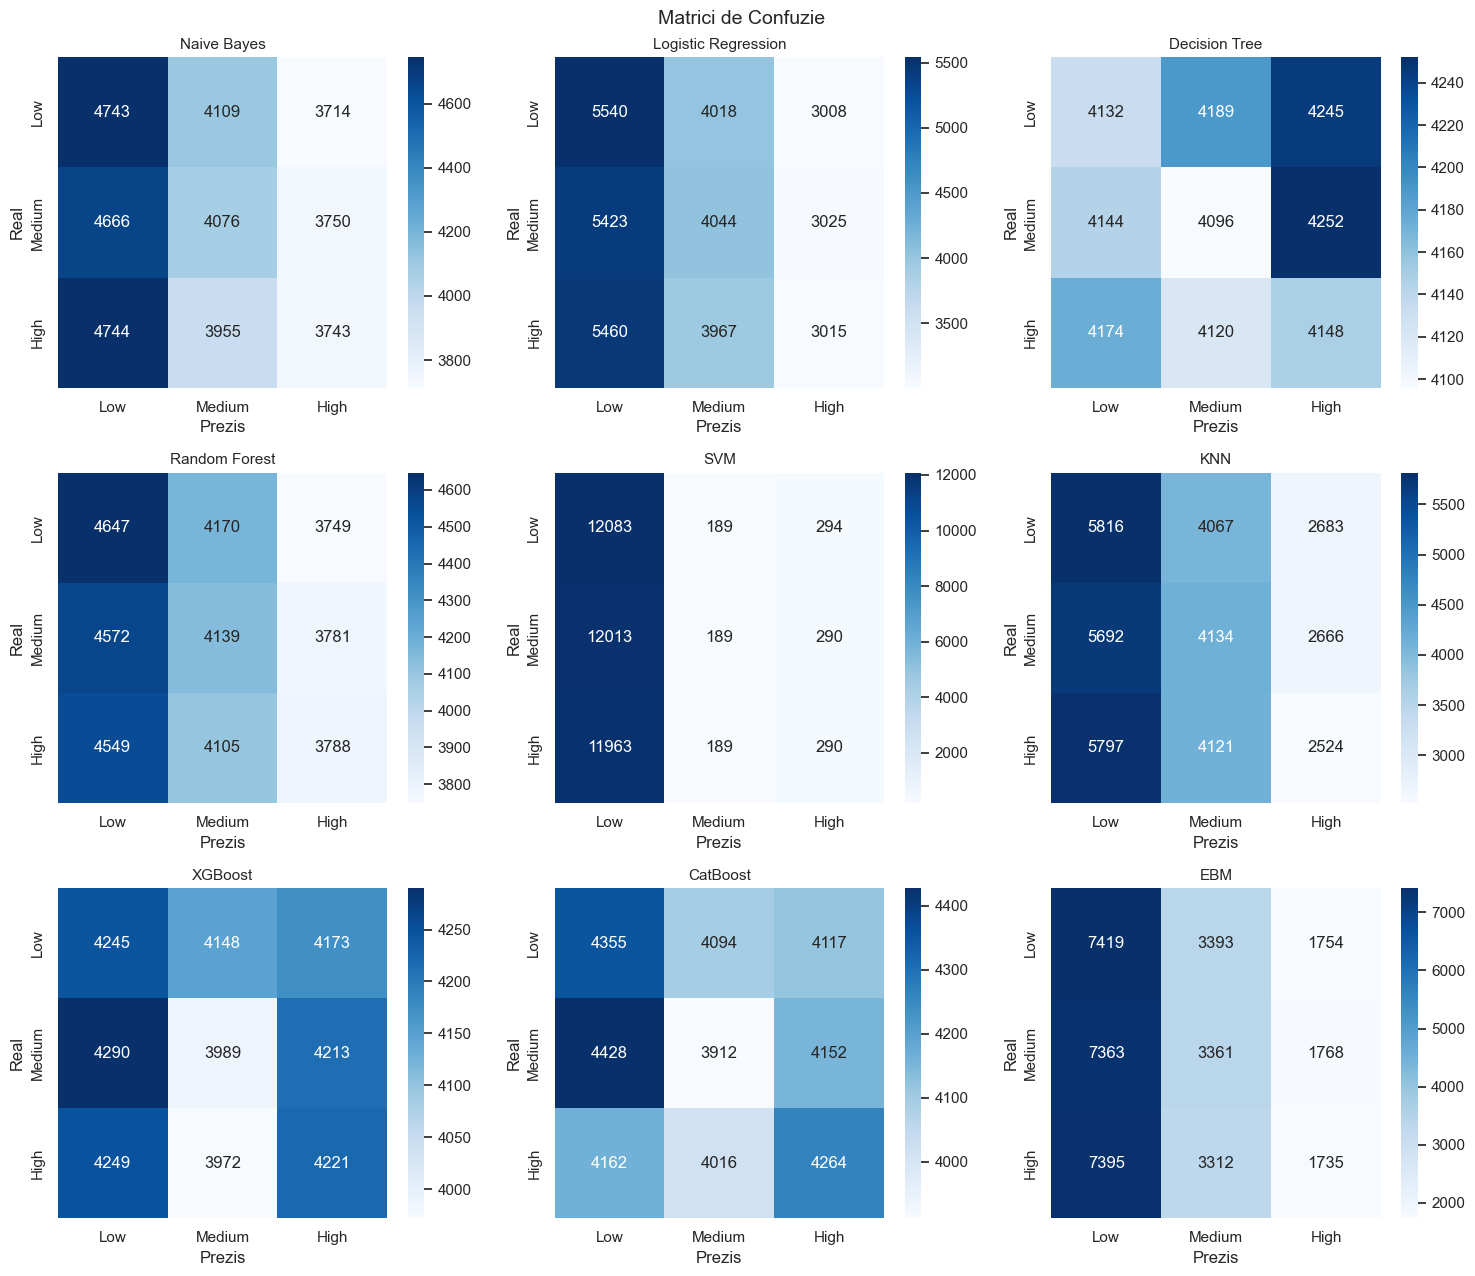

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()
labels = ['Low', 'Medium', 'High']

for i, (name, (model, y_pred)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Prezis')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrici de Confuzie', fontsize=14)
plt.tight_layout()
plt.show()

## 3.4 Tabel Markdown top 5

In [31]:
top5 = df_results.head(5).copy()
for col in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']:
    top5[col] = top5[col].map('{:.4f}'.format)
print(top5.to_markdown())

|    | Model               |   Accuracy |   Precision |   Recall |   F1 Score |   ROC-AUC |
|---:|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
|  1 | Random Forest       |     0.3353 |      0.3352 |   0.3353 |     0.3348 |    0.5012 |
|  2 | Naive Bayes         |     0.335  |      0.335  |   0.335  |     0.3342 |    0.5004 |
|  3 | CatBoost            |     0.3342 |      0.334  |   0.3342 |     0.334  |    0.5015 |
|  4 | XGBoost             |     0.3321 |      0.3321 |   0.3321 |     0.3321 |    0.4999 |
|  5 | Logistic Regression |     0.336  |      0.3356 |   0.336  |     0.3311 |    0.5007 |


---
# 4. Ajustarea hiperparametrilor

In [32]:
# Importuri
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4.1 Logistic Regression — GridSearchCV

In [33]:
# Puțini hiperparametri → Grid e suficient
#GridSearchCV încearcă toate combinațiile posibile de hiperparametri și le evaluează prin cross-validation, returnând cea mai bună combinație.
# C = inversul regularizării — valori mici înseamnă regularizare puternică, valori mari înseamnă regularizare slabă
# penalty = tipul de regularizare (L1 = Lasso, L2 = Ridge)
# solver = algoritmul folosit pentru optimizare (liblinear și saga suportă atât L1 cât și L2)

param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear', 'saga']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_scaled, y_train)

print(f'✅ Best params: {grid_lr.best_params_}')
print(f'   Best CV F1:  {grid_lr.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
   Best CV F1:  0.3268


## 4.2 Naive Bayes — GridSearchCV

In [34]:
# var_smoothing adaugă o valoare mică la varianța fiecărui feature ca să evite probabilități de exact 0:
param_grid_nb = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_nb.fit(X_train_scaled, y_train)

print(f'✅ Best params: {grid_nb.best_params_}')
print(f'   Best CV F1:  {grid_nb.best_score_:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
✅ Best params: {'var_smoothing': 1e-11}
   Best CV F1:  0.3283


## 4.3 Random Forest — BayesSearchCV

In [ ]:
# max_depth — adâncimea maximă a fiecărui arbore
# min_samples_split — minim de exemple pentru a împărți un nod
# min_samples_leaf — minim de exemple într-o frunză finală
# max_features — câte features ia în considerare la fiecare split

param_bayes_rf = {
    'n_estimators':      Integer(100, 500),
    'max_depth':         Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf':  Integer(1, 10),
    'max_features':      Categorical(['sqrt', 'log2'])
}

bayes_rf = BayesSearchCV(
    RandomForestClassifier(random_state=42),
    param_bayes_rf,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
bayes_rf.fit(X_train_scaled, y_train)

print(f'✅ Best params: {bayes_rf.best_params_}')
print(f'   Best CV F1:  {bayes_rf.best_score_:.4f}')

Fitting 3 folds for each of 1 candidates, totalling 3 fits


## 4.4 XGBoost — BayesSearchCV

In [ ]:
# n_estimators — numărul de arbori
# max_depth — adâncimea arborelui
# learning_rate — cât de mult corectează fiecare arbore nou
# subsample — ce % din date folosește fiecare arbore
# colsample_bytree — ce % din features folosește fiecare arbore
# reg_alpha — regularizare L1
# reg_lambda — regularizare L2

param_bayes_xgb = {
    'n_estimators':     Integer(100, 500),
    'max_depth':        Integer(3, 10),
    'learning_rate':    Real(0.01, 0.3, prior='log-uniform'),
    'subsample':        Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha':        Real(0, 1),
    'reg_lambda':       Real(1, 5)
}

bayes_xgb = BayesSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    param_bayes_xgb,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Subset 20.000 rânduri
from sklearn.utils import resample

X_sample, y_sample = resample(
    X_train_scaled, y_train,
    n_samples=20000,
    random_state=42,
    stratify=y_train
)

bayes_xgb.fit(X_sample, y_sample)  # ← subset, nu tot train-ul

print(f'✅ Best params: {bayes_xgb.best_params_}')
print(f'   Best CV F1:  {bayes_xgb.best_score_:.4f}')

## 4.5 CatBoost — BayesSearchCV

In [ ]:
# iterations — numărul de arbori
# depth — adâncimea arborelui
# learning_rate — viteza de învățare
# l2_leaf_reg — regularizare L2
# bagging_temperature — specific CatBoost, nu există la XGBoost

param_bayes_cat = {
    'iterations':          Integer(100, 500),
    'depth':               Integer(3, 10),
    'learning_rate':       Real(0.01, 0.3, prior='log-uniform'),
    'l2_leaf_reg':         Real(1, 10),
    'bagging_temperature': Real(0, 1)
}

bayes_cat = BayesSearchCV(
    CatBoostClassifier(random_state=42, verbose=0),
    param_bayes_cat,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# X_sample și y_sample sunt deja create de la XGBoost
# nu mai trebuie să le recreezi
bayes_cat.fit(X_sample, y_sample)

print(f'✅ Best params: {bayes_cat.best_params_}')
print(f'   Best CV F1:  {bayes_cat.best_score_:.4f}')

## 4.6 Compararea performanțelor după ajustarea hiperparametrilor

In [ ]:
tuned_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Naive Bayes':         grid_nb.best_estimator_,
    'Random Forest':       bayes_rf.best_estimator_,
    'XGBoost':             bayes_xgb.best_estimator_,
    'CatBoost':            bayes_cat.best_estimator_,
}

tuned_results = []
print('📊 Verificare overfitting (Train vs Test F1):\n')

for name, model in tuned_models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    test_f1  = f1_score(y_test, y_pred, average='weighted')
    train_f1 = cross_val_score(
                   model, X_train_scaled, y_train,
                   cv=3, scoring='f1_weighted',
                   n_jobs=-1
               ).mean()
    diff   = train_f1 - test_f1
    status = '⚠️ overfit' if diff > 0.05 else '✅ ok'

    print(f'  {name:<22} Train: {train_f1:.4f}  Test: {test_f1:.4f}  Δ={diff:.4f}  {status}')

    tuned_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall':    recall_score(y_test, y_pred, average='weighted'),
        'F1 Score':  test_f1,
        'ROC-AUC':   roc_auc_score(y_test, y_proba,
                                    multi_class='ovr', average='weighted')
    })

df_tuned = (pd.DataFrame(tuned_results)
              .sort_values('F1 Score', ascending=False)
              .reset_index(drop=True))
df_tuned.index += 1
print('\n')
print(df_tuned.to_string())

---
# 5. Curbe de învățare

!!! Note:

        Curba de învățare arată cum evoluează performanța modelului pe setul de antrenament și testare pe măsură ce crește numărul
    de dateccde antrenament. Dacă curba de antrenament e sus și cea de test e jos, modelul e subantrenat. Dacă ambele sunt sus dar
    distanțate, modelul e overfit. Dacă ambele sunt aproape și sus, modelul e bine antrenat.

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Cele 5 modele tuned ale tale
tuned_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Naive Bayes':         grid_nb.best_estimator_,
    'Random Forest':       bayes_rf.best_estimator_,
    'XGBoost':             bayes_xgb.best_estimator_,
    'CatBoost':            bayes_cat.best_estimator_,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Folosim un subset pentru viteză — 30k rânduri suficiente
N = 30000
idx = np.random.choice(len(X_train_scaled), N, replace=False)
X_lc = X_train_scaled[idx]
y_lc = np.array(y_train)[idx]

train_sizes_pct = np.linspace(0.1, 1.0, 8)  # 10%, 20%, ... 100%

for i, (name, model) in enumerate(tuned_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_lc, y_lc,
        train_sizes=train_sizes_pct,
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    # Medie și deviație standard
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax = axes[i]

    # Curbe
    ax.plot(train_sizes, train_mean, 'o-', color='steelblue',
            label='Train', linewidth=2)
    ax.plot(train_sizes, val_mean, 'o--', color='coral',
            label='Validare', linewidth=2)

    # Intervale de încredere (±1 std)
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='coral')

    # Diferența train-val la final
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.05:
        status = '⚠️ Overfit'
        color  = 'red'
    elif val_mean[-1] < 0.6:
        status = '⚠️ Underfit'
        color  = 'orange'
    else:
        status = '✅ OK'
        color  = 'green'

    ax.set_title(f'{name}\n'
                 f'Train={train_mean[-1]:.3f} | Val={val_mean[-1]:.3f} | '
                 f'Δ={gap:.3f} → {status}',
                 fontsize=10, color=color)
    ax.set_xlabel('Număr exemple antrenare')
    ax.set_ylabel('F1 Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

# Ascunde ultimul subplot gol
axes[-1].set_visible(False)

plt.suptitle('Curbe de Învățare — Top 5 Modele', fontsize=15)
plt.tight_layout()
plt.show()

!!! Interpretare

    1. Unde pornesc cele două curbe (la date puține)?
    → dacă train pornește de la 1.0 și val de la 0.4 → semn clar de overfit

    2. Cum evoluează pe măsură ce cresc datele?
    → dacă val crește constant → modelul beneficiază de mai multe date
    → dacă val stagnează → modelul a atins limita

    3. Care e gap-ul final (Δ)?
    → Δ < 0.05 → ok
    → Δ 0.05-0.10 → ușor overfit
    → Δ > 0.10 → overfit semnificativ

---
# 6. Explicabilitatea și analiza SHAP

In [4]:
import shap
shap.initjs()

In [5]:
#Primele 3 modele
top3_models = {
    'Random Forest': bayes_rf.best_estimator_,
    'XGBoost':       bayes_xgb.best_estimator_,
    'CatBoost':      bayes_cat.best_estimator_,
}

#Folosim un subset pentru viteză
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_explain  = X_test_df.sample(500, random_state=42)  # 500 exemple suficiente

NameError: name 'bayes_rf' is not defined

## 6.1 Random Forest — SHAP complet

In [ ]:
print('=' * 50)
print('SHAP — Random Forest')
print('=' * 50)

explainer_rf   = shap.TreeExplainer(bayes_rf.best_estimator_)
shap_values_rf = explainer_rf.shap_values(X_explain)

# Global 1: Summary Plot (beeswarm)
# Arată distribuția valorilor SHAP per feature
plt.figure()
shap.summary_plot(
    shap_values_rf,
    X_explain,
    class_names=['Low', 'Medium', 'High'],
    show=True
)

# Global 2: Bar Plot
# Arată importanța medie absolută per feature
plt.figure()
shap.summary_plot(
    shap_values_rf,
    X_explain,
    plot_type='bar',
    class_names=['Low', 'Medium', 'High'],
    show=True
)

# Local: Waterfall Plot (primul exemplu)
# Explică O singură predicție
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_rf[2][0],        # clasa High, primul exemplu
        base_values=explainer_rf.expected_value[2],
        data=X_explain.iloc[0],
        feature_names=X_explain.columns.tolist()
    )
)

# Local: Force Plot
shap.force_plot(
    explainer_rf.expected_value[2],
    shap_values_rf[2][0],
    X_explain.iloc[0],
    feature_names=X_explain.columns.tolist(),
    matplotlib=True
)
plt.title('Force Plot — Random Forest — primul exemplu')
plt.tight_layout()
plt.show()

# Scatter Plots pentru top 3 features
importances_rf = np.abs(shap_values_rf[2]).mean(axis=0)
top3_features_rf = X_explain.columns[np.argsort(importances_rf)[-3:]].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_features_rf):
    shap.dependence_plot(
        feat,
        shap_values_rf[2],
        X_explain,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Scatter SHAP — {feat}')
plt.suptitle('SHAP Scatter Plots — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Top 3 features RF: {top3_features_rf}')

In [ ]:
print('=' * 50)
print('SHAP — XGBoost')
print('=' * 50)

explainer_xgb   = shap.TreeExplainer(bayes_xgb.best_estimator_)
shap_values_xgb = explainer_xgb.shap_values(X_explain)

# Global 1: Summary Plot
plt.figure()
shap.summary_plot(
    shap_values_xgb,
    X_explain,
    class_names=['Low', 'Medium', 'High'],
    show=True
)

# Global 2: Bar Plot
plt.figure()
shap.summary_plot(
    shap_values_xgb,
    X_explain,
    plot_type='bar',
    class_names=['Low', 'Medium', 'High'],
    show=True
)

# Local: Waterfall Plot
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_xgb[2][0],
        base_values=explainer_xgb.expected_value[2],
        data=X_explain.iloc[0],
        feature_names=X_explain.columns.tolist()
    )
)

# Local: Force Plot
shap.force_plot(
    explainer_xgb.expected_value[2],
    shap_values_xgb[2][0],
    X_explain.iloc[0],
    feature_names=X_explain.columns.tolist(),
    matplotlib=True
)
plt.title('Force Plot — XGBoost — primul exemplu')
plt.tight_layout()
plt.show()

# Scatter Plots
importances_xgb  = np.abs(shap_values_xgb[2]).mean(axis=0)
top3_features_xgb = X_explain.columns[np.argsort(importances_xgb)[-3:]].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_features_xgb):
    shap.dependence_plot(
        feat,
        shap_values_xgb[2],
        X_explain,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Scatter SHAP — {feat}')
plt.suptitle('SHAP Scatter Plots — XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Top 3 features XGB: {top3_features_xgb}')

## 6.2 XGBoost — SHAP complet

## 6.3 CatBoost — SHAP complet

In [ ]:
print('=' * 50)
print('SHAP — CatBoost')
print('=' * 50)

explainer_cat   = shap.TreeExplainer(bayes_cat.best_estimator_)
shap_values_cat = explainer_cat.shap_values(X_explain)

# Global 1: Summary Plot
plt.figure()
shap.summary_plot(
    shap_values_cat,
    X_explain,
    class_names=['Low', 'Medium', 'High'],
    show=True
)

# Global 2: Bar Plot
plt.figure()
shap.summary_plot(
    shap_values_cat,
    X_explain,
    plot_type='bar',
    class_names=['Low', 'Medium', 'High'],
    show=True
)

# Local: Waterfall Plot
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_cat[2][0],
        base_values=explainer_cat.expected_value[2],
        data=X_explain.iloc[0],
        feature_names=X_explain.columns.tolist()
    )
)

# Local: Force Plot
shap.force_plot(
    explainer_cat.expected_value[2],
    shap_values_cat[2][0],
    X_explain.iloc[0],
    feature_names=X_explain.columns.tolist(),
    matplotlib=True
)
plt.title('Force Plot — CatBoost — primul exemplu')
plt.tight_layout()
plt.show()

# Scatter Plots
importances_cat   = np.abs(shap_values_cat[2]).mean(axis=0)
top3_features_cat = X_explain.columns[np.argsort(importances_cat)[-3:]].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_features_cat):
    shap.dependence_plot(
        feat,
        shap_values_cat[2],
        X_explain,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Scatter SHAP — {feat}')
plt.suptitle('SHAP Scatter Plots — CatBoost', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Top 3 features CAT: {top3_features_cat}')

Summary Plot:

    Axa X  → valoarea SHAP (negativ = împinge spre Low, pozitiv = spre High)
    Culoare→ roșu = valoare mare a featurei, albastru = valoare mică
    Fiecare punct = un student din setul de test

Exemplu de interpretare:
    "anxiety_score apare sus în grafic → feature importantă
     Punctele roșii (anxiety mare) au SHAP pozitiv → împing predicția spre High burnout
     Punctele albastre (anxiety mic) au SHAP negativ → împing spre Low burnout"

Waterfall Plot:

    Pornește de la E[f(x)] = valoarea medie de bază a modelului
    Fiecare feature adaugă sau scade din această valoare de bază
    Săgețile roșii  → feature împinge predicția în SUS  (spre High)
    Săgețile albastre → feature împinge predicția în JOS (spre Low)
    Valoarea finală f(x) = predicția pentru acel student

Force Plot:

    Aceleași informații ca Waterfall dar vizualizare orizontală
    Roșu  → forțe care împing spre High burnout
    Albastru → forțe care împing spre Low burnout
    Lățimea săgeții = importanța contribuției

Scatter Plot:

    Axa X → valoarea featurei (ex: anxiety_score de la 1 la 10)
    Axa Y → valoarea SHAP (contribuția la predicție)

    Dacă linia e crescătoare → valori mari ale featurei = SHAP pozitiv = crește burnout
    Dacă linia e descrescătoare → valori mari = SHAP negativ = scade burnout

In [1]:
import joblib

# ── Din notebook-ul de clasificare ───────────────────
clf_models_to_save = {
    'Random Forest':       bayes_rf.best_estimator_,
    'Naive Bayes':         grid_nb.best_estimator_,
    'CatBoost':            bayes_cat.best_estimator_,
    'XGBoost':             bayes_xgb.best_estimator_,
    'Logistic Regression': grid_lr.best_estimator_,
}
joblib.dump(clf_models_to_save, 'models/clf_models.pkl')
joblib.dump(scaler,             'models/clf_scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/clf_feature_names.pkl')
print('✅ Modele clasificare salvate!')

NameError: name 'bayes_rf' is not defined